In [ ]:
!pip install kagglehub tensorflow matplotlib seaborn scikit-learn pillow

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import kagglehub

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

data_dir = os.path.join(path, "PlantVillage", "PlantVillage")
print("Dataset:", data_dir)

100%|██████████| 75.7M/75.7M [00:03<00:00, 24.8MB/s]

Extracting files...


Dataset: /root/.cache/kagglehub/datasets/hafiznouman786/potato-plant-diseases-data/versions/2/PlantVillage/PlantVillage


In [ ]:
healthy_path = os.path.join(data_dir, "Potato___healthy")

images = [f for f in os.listdir(healthy_path) if f.endswith(('jpg','png','jpeg'))]

# Oversample Healthy class
for i in range(5):  # increase count
    for img in images:
        src = os.path.join(healthy_path, img)
        dst = os.path.join(healthy_path, f"copy_{i}_{img}")
        if not os.path.exists(dst):
            shutil.copy(src, dst)

print("Healthy class balanced!")

Healthy class balanced!


In [ ]:
print(os.listdir(data_dir))

['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


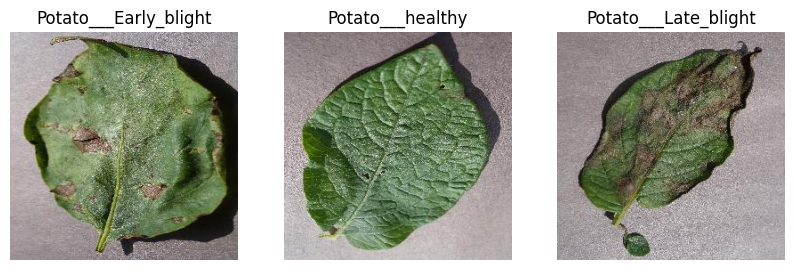

In [ ]:
plt.figure(figsize=(10,5))

classes = os.listdir(data_dir)

for i, cls in enumerate(classes):
    class_path = os.path.join(data_dir, cls)

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png','.jpg','.jpeg'))]

    img_path = os.path.join(class_path, random.choice(images))
    img = Image.open(img_path)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    zoom_range=0.4,
    shear_range=0.3,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.5,1.5]
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.


In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.5488 - loss: 1.1152 - val_accuracy: 0.7279 - val_loss: 0.6215
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7346 - loss: 0.6568 - val_accuracy: 0.8465 - val_loss: 0.4515
Epoch 3/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7805 - loss: 0.5552 - val_accuracy: 0.8791 - val_loss: 0.3491
Epoch 4/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.7886 - loss: 0.5233 - val_accuracy: 0.9256 - val_loss: 0.2590
Epoch 5/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8258 - loss: 0.4182 - val_accuracy: 0.9140 - val_loss: 0.2457
Epoch 6/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.8577 - loss: 0.3778 - val_accuracy: 0.9395 - val_loss: 0.2196
Epoch 7/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8751 - loss: 0.3221 - val_accuracy: 0.9349 - val_loss: 0.1751
Epoch 8/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8775 - loss: 0.3255 - val_accuracy: 0.9372 - v

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.8240 - loss: 0.4861 - val_accuracy: 0.9395 - val_loss: 0.1519
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.8647 - loss: 0.3745 - val_accuracy: 0.9326 - val_loss: 0.1485
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.8833 - loss: 0.3089 - val_accuracy: 0.9628 - val_loss: 0.1041
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.8891 - loss: 0.2876 - val_accuracy: 0.9395 - val_loss: 0.1161
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.9013 - loss: 0.2632 - val_accuracy: 0.9581 - val_loss: 0.1351
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9042 - loss: 0.2598 - val_accuracy: 0.9558 - val_loss: 0.1277
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.9036 - loss: 0.2635 - val_accuracy: 0.9488 - val_loss: 0.1707
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.9053 - loss: 0.2461 - val_accuracy: 0.9395 - v

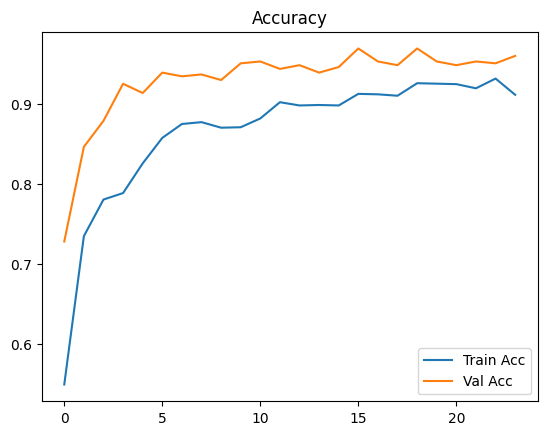

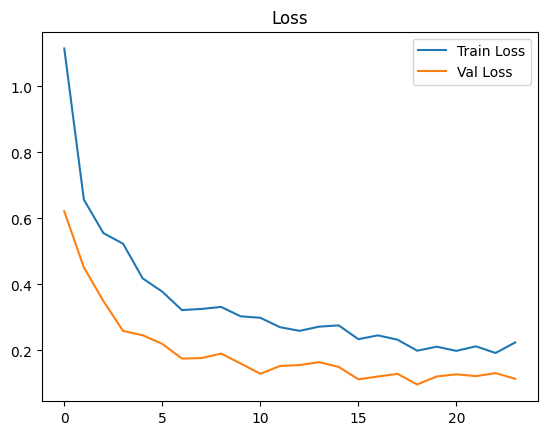

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
val_data.reset()
preds = model.predict(val_data)

y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

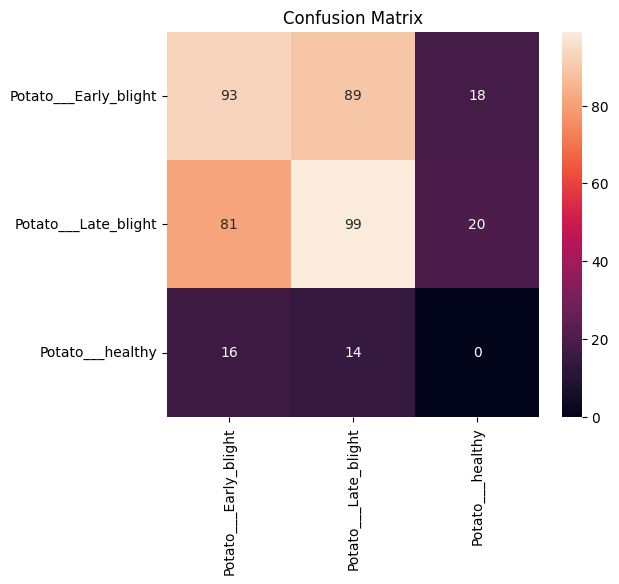

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())

plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=val_data.class_indices.keys()))

                       precision    recall  f1-score   support

Potato___Early_blight       0.49      0.47      0.48       200
 Potato___Late_blight       0.49      0.49      0.49       200
     Potato___healthy       0.00      0.00      0.00        30

             accuracy                           0.45       430
            macro avg       0.33      0.32      0.32       430
         weighted avg       0.46      0.45      0.45       430



In [ ]:
model.save("potato_model_final.h5")

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_names = list(train_data.class_indices.keys())

    print("Prediction:", class_names[np.argmax(pred)])

In [ ]:
predict_image(r"C:\Users\91636\Downloads\potato\PotatoPlants\Potato___Early_blight\f0cdbf74-8401-48d1-b1cc-94862e1a4452___RS_Early.B 7447.JPG")